Математическое ожидание: 2.08
Дисперсия: 1.4336000000000002


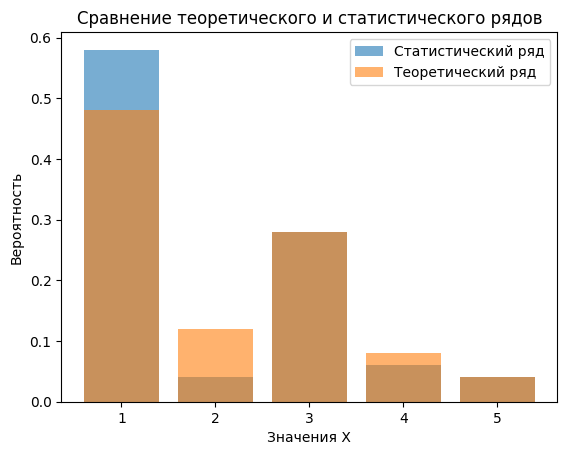

Для ε = 0.5: Вероятность = 0.88, Теоретическая граница = 5.734400000000001
Для ε = 0.7: Вероятность = 0.88, Теоретическая граница = 2.9257142857142866
Для ε = 0.9: Вероятность = 0.88, Теоретическая граница = 1.7698765432098766
Для ε = 1: Вероятность = 0.6, Теоретическая граница = 1.4336000000000002
Для ε = 1.5: Вероятность = 0.12, Теоретическая граница = 0.6371555555555557
Для ε = 2: Вероятность = 0.04, Теоретическая граница = 0.35840000000000005
Для ε = 0.5: Вероятность = 0.04, Теоретическая граница = 0.35840000000000005
Для ε = 0.7: Вероятность = 0.04, Теоретическая граница = 0.35840000000000005
Для ε = 0.9: Вероятность = 0.04, Теоретическая граница = 0.35840000000000005
Для ε = 1: Вероятность = 0.04, Теоретическая граница = 0.35840000000000005
Для ε = 1.5: Вероятность = 0.04, Теоретическая граница = 0.35840000000000005
Для ε = 2: Вероятность = 0.04, Теоретическая граница = 0.35840000000000005


In [6]:
# Задание 1
import numpy as np
import matplotlib.pyplot as plt

# Словарь для преобразования букв в числа
letter_to_number = {
    'А': 1, 'Б': 1, 'В': 1, 'Г': 1, 'Д': 1, 'Е': 1,
    'Ё': 2, 'Ж': 2, 'З': 2, 'И': 2, 'Й': 2, 'К': 2,
    'Л': 3, 'М': 3, 'Н': 3, 'О': 3, 'П': 3, 'Р': 3,
    'С': 4, 'Т': 4, 'У': 4, 'Ф': 4, 'Х': 4, 'Ц': 4,
    'Ч': 5, 'Ш': 5, 'Щ': 5, 'Ъ': 5, 'Ы': 5, 'Ь': 5,
    'Э': 6, 'Ю': 6, 'Я': 6
}

# Мое имя
name = "ВЛАДИСЛАВ СЕРГЕЕВИЧ КОРОБОВ"
letters = [char for char in name if char.isalpha()]  # Выбираем только буквы

# Преобразуем буквы в числа
numbers = [letter_to_number[char] for char in letters]

# Подсчитываем частоты
frequency = {}
for num in numbers:
    if num in frequency:
        frequency[num] += 1
    else:
        frequency[num] = 1

# Общее количество карточек
total_cards = len(numbers)

# Теоретическое распределение
pmf = {key: value / total_cards for key, value in frequency.items()}

# Математическое ожидание
expected_value = sum(x * p for x, p in pmf.items())

# Дисперсия
second_moment = sum(x**2 * p for x, p in pmf.items())
variance = second_moment - expected_value**2

print(f"Математическое ожидание: {expected_value}")
print(f"Дисперсия: {variance}")

# Генерация выборки объема 50
sample = []
for _ in range(50):
    rand_num = np.random.rand()
    cumulative_probability = 0
    for key, prob in pmf.items():
        cumulative_probability += prob
        if rand_num <= cumulative_probability:
            sample.append(key)
            break

# Подсчитываем частоты выборки
sample_frequency = {}
for num in sample:
    if num in sample_frequency:
        sample_frequency[num] += 1
    else:
        sample_frequency[num] = 1

# Статистический ряд
sample_pmf = {key: value / len(sample) for key, value in sample_frequency.items()}

# Визуализация
plt.bar(sample_pmf.keys(), sample_pmf.values(), alpha=0.6, label='Статистический ряд')
plt.bar(pmf.keys(), pmf.values(), alpha=0.6, label='Теоретический ряд')
plt.legend()
plt.xlabel('Значения X')
plt.ylabel('Вероятность')
plt.title('Сравнение теоретического и статистического рядов')
plt.show()

# Проверка теоремы Чебышёва
epsilon_values = [0.5, 0.7, 0.9, 1, 1.5, 2]
results = []
results1 = []


for epsilon in epsilon_values:
    theoretical_bound = variance / epsilon**2 # Теоретическая граница 2 неравенства Чебышева
    actual_probability = sum(p for x, p in pmf.items() if abs(x - expected_value) >= epsilon) # Находим вероятность отклонения от матожидания
    results.append((epsilon, actual_probability, theoretical_bound))
for epsilon in epsilon_values:
    theoretical_bound1 = expected_value / epsilon # Теоретическая граница 1 неравенства Чебышева
    actual_probability1 = sum(p for x, p in pmf.items() if abs(x) >= epsilon) # Находим вероятность отклонения от epsilon
    results1.append((epsilon, actual_probability, theoretical_bound))

# Вывод результатов проверки теоремы Чебышёва
for epsilon, actual, bound in results:
    print(f"Для ε = {epsilon}: Вероятность = {actual}, Теоретическая граница = {bound}")
for epsilon, actual, bound in results1:
    print(f"Для ε = {epsilon}: Вероятность = {actual}, Теоретическая граница = {bound}")